# Regression Tree
Ajit Kumar @ ICT Mumbai

**Problem Description**

We consider a regression problem in which the objective is to predict the
**final exam score** of a student based on three explanatory variables:

* $x_1$: Hours of Study per Week
* $x_2$: Attendance Percentage
* $x_3$: Assignment Score

The response variable is: $y = \text{Final Exam Score}$

In [13]:
import pandas as pd
import numpy as np

In [14]:
data = pd.DataFrame({
    "StudyHours": [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    "Attendance": [60,65,70,75,80,85,88,90,92,94,95,96,97,98,99,99,100,100,100],
    "Assignment": [55,60,58,62,65,70,72,75,78,80,82,85,88,90,92,94,95,97,98],
    "FinalScore": [50,52,54,58,60,65,68,70,73,75,78,80,82,85,88,90,92,94,96]
})

data

,StudyHours,Attendance,Assignment,FinalScore
0,2,60,55,50
1,3,65,60,52
2,4,70,58,54
3,5,75,62,58
4,6,80,65,60
5,7,85,70,65
6,8,88,72,68
7,9,90,75,70
8,10,92,78,73
9,11,94,80,75


In [3]:
def variance(y):
    mean_y = np.mean(y)
    return np.mean((y - mean_y)**2)

In [15]:
def weighted_variance(left, right):
    n = len(left) + len(right)
    return (len(left)/n)*variance(left) + (len(right)/n)*variance(right)

In [16]:
root_variance = variance(data["FinalScore"])
root_variance

207.53462603878117

In [17]:
splits = sorted(data["StudyHours"].unique())

results = []

for s in splits[:-1]:
    left = data[data["StudyHours"] <= s]["FinalScore"]
    right = data[data["StudyHours"] > s]["FinalScore"]
    
    wv = weighted_variance(left, right)
    results.append((s, wv))

In [18]:
split_df = pd.DataFrame(results, columns=["Split (StudyHours ≤ s)", "Weighted Variance"])
split_df.sort_values("Weighted Variance")

,Split (StudyHours ≤ s),Weighted Variance
7,9,52.816388
8,10,53.099415
9,11,55.160819
6,8,56.935464
10,12,61.620215
5,7,62.767206
11,13,69.892857
4,6,72.974436
12,14,80.003374
3,5,93.154386


In [19]:
left_node = data[data["StudyHours"] <= 10]["FinalScore"]
right_node = data[data["StudyHours"] > 10]["FinalScore"]

left_prediction = left_node.mean()
right_prediction = right_node.mean()

left_prediction, right_prediction

(61.111111111111114, 86.0)

In [20]:
right_data = data[data["StudyHours"] > 10]

results_level2 = []

for s in sorted(right_data["Attendance"].unique())[:-1]:
    left = right_data[right_data["Attendance"] <= s]["FinalScore"]
    right = right_data[right_data["Attendance"] > s]["FinalScore"]
    
    results_level2.append((s, weighted_variance(left, right)))

pd.DataFrame(results_level2,
             columns=["Attendance ≤ s", "Weighted Variance"]).sort_values("Weighted Variance")

,Attendance ≤ s,Weighted Variance
4,98,9.800000
3,97,10.758333
2,96,16.038095
5,99,18.371429
1,95,23.237500
0,94,32.355556


## Regression Tree using sklearn

In [21]:
from sklearn.tree import DecisionTreeRegressor

In [23]:
X = data[["StudyHours", "Attendance", "Assignment"]]
y = data["FinalScore"]

tree = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=3,
    min_samples_leaf=2,
    random_state=0
)

tree.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

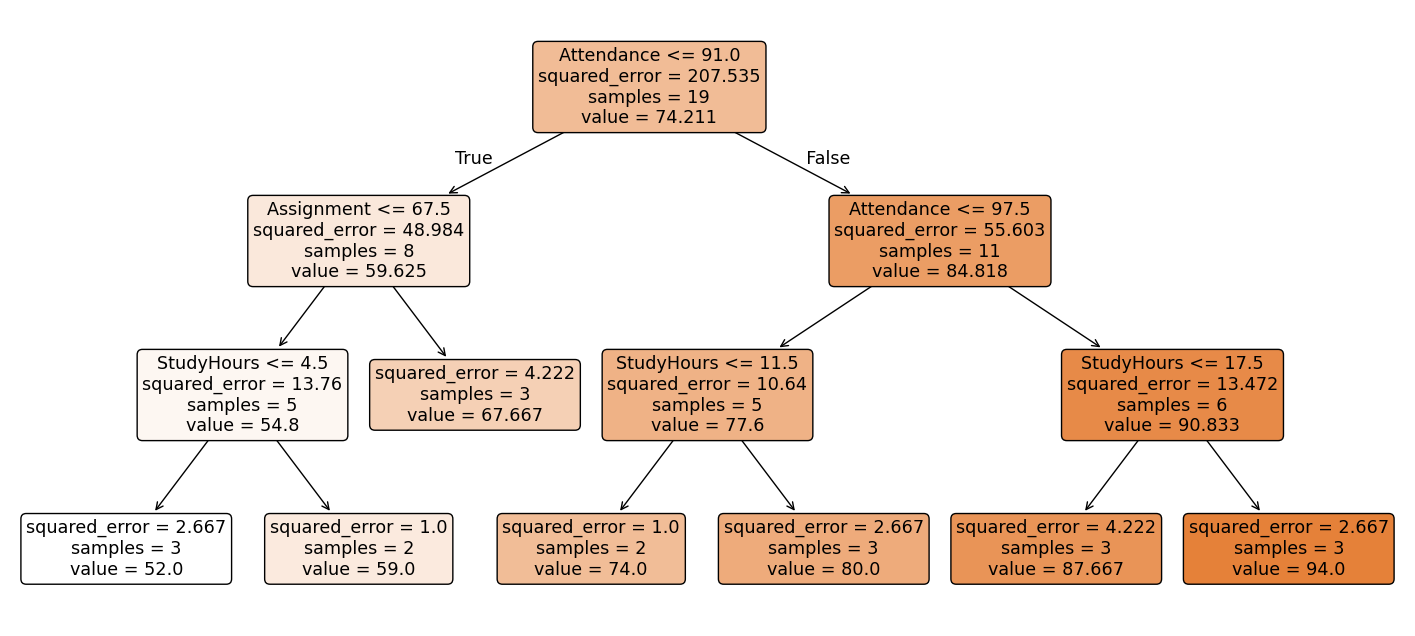

In [25]:
plt.figure(figsize=(18,8))
plot_tree(
    tree,
    feature_names=X.columns,
    filled=True,
    rounded=True
)
plt.show()

In [26]:
tree.predict(X)

array([52.        , 52.        , 52.        , 59.        , 59.        ,
       67.66666667, 67.66666667, 67.66666667, 74.        , 74.        ,
       80.        , 80.        , 80.        , 87.66666667, 87.66666667,
       87.66666667, 94.        , 94.        , 94.        ])

In [27]:
# New student
new_student = pd.DataFrame({
    "StudyHours": [14],
    "Attendance": [95],
    "Assignment": [88]
})

tree.predict(new_student)

array([80.])

In [28]:
tree.get_n_leaves()

7

In [29]:
tree.get_depth()

3

### Regression Tree on Hitters Data

In [30]:
# Load dataset
hitters = pd.read_csv("Hitters.csv")
print(hitters.shape)
hitters.head()


(322, 20)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [31]:
data = hitters[["Years", "Hits", "Salary"]]

# Remove missing values (Salary has missing entries)
data = data.dropna()

data.shape

(263, 3)

In [32]:
X = data[["Years", "Hits"]]
y = data["Salary"]

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

In [35]:
tree_reg = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=4,          # controlled depth for interpretability
    min_samples_leaf=10,  # avoid overfitting
    random_state=0
)

tree_reg.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf

In [36]:
y_pred = tree_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

rmse, r2

(412.2104177992888, 0.35621221369075085)

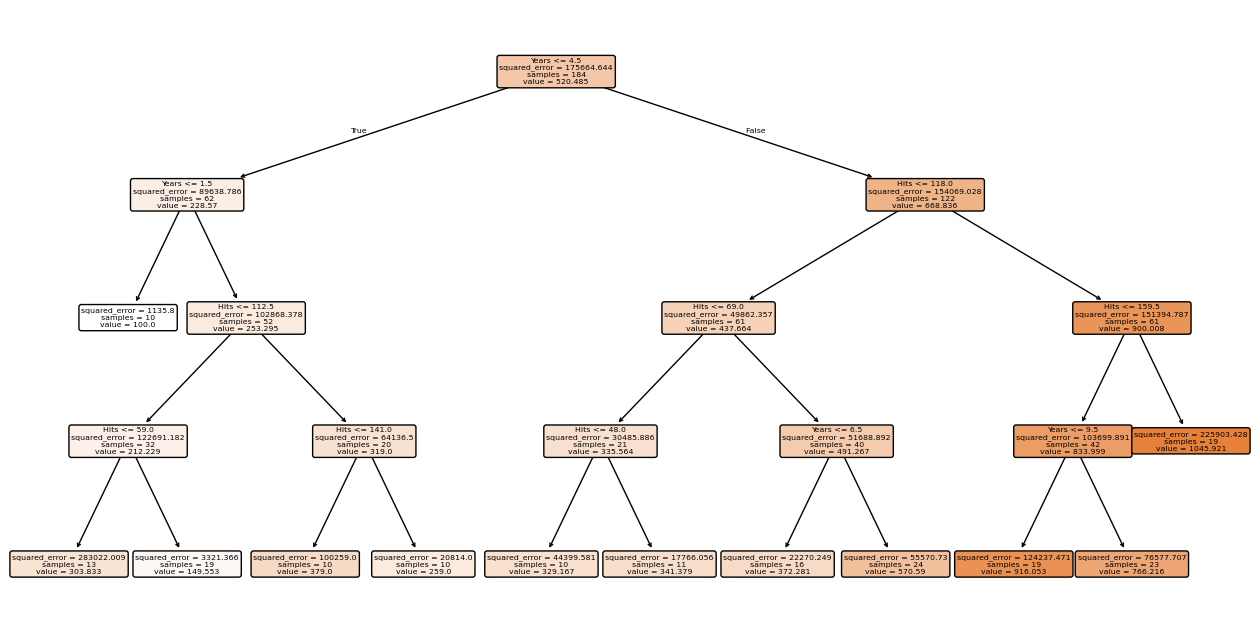

In [37]:
plt.figure(figsize=(16,8))
plot_tree(
    tree_reg,
    feature_names=["Years", "Hits"],
    filled=True,
    rounded=True
)
plt.show()

In [38]:
from sklearn.tree import export_text

rules = export_text(tree_reg, feature_names=["Years", "Hits"])
print(rules)

|--- Years <= 4.50
|   |--- Years <= 1.50
|   |   |--- value: [100.00]
|   |--- Years >  1.50
|   |   |--- Hits <= 112.50
|   |   |   |--- Hits <= 59.00
|   |   |   |   |--- value: [303.83]
|   |   |   |--- Hits >  59.00
|   |   |   |   |--- value: [149.55]
|   |   |--- Hits >  112.50
|   |   |   |--- Hits <= 141.00
|   |   |   |   |--- value: [379.00]
|   |   |   |--- Hits >  141.00
|   |   |   |   |--- value: [259.00]
|--- Years >  4.50
|   |--- Hits <= 118.00
|   |   |--- Hits <= 69.00
|   |   |   |--- Hits <= 48.00
|   |   |   |   |--- value: [329.17]
|   |   |   |--- Hits >  48.00
|   |   |   |   |--- value: [341.38]
|   |   |--- Hits >  69.00
|   |   |   |--- Years <= 6.50
|   |   |   |   |--- value: [372.28]
|   |   |   |--- Years >  6.50
|   |   |   |   |--- value: [570.59]
|   |--- Hits >  118.00
|   |   |--- Hits <= 159.50
|   |   |   |--- Years <= 9.50
|   |   |   |   |--- value: [916.05]
|   |   |   |--- Years >  9.50
|   |   |   |   |--- value: [766.22]
|   |   |--- Hits >

In [39]:
# Player with 8 years experience and 120 hits
new_player = pd.DataFrame({
    "Years": [8],
    "Hits": [120]
})

tree_reg.predict(new_player)

array([916.05257895])